# Task 4 Visualizations Notebook (Updated for reviews_with_sentiment.csv)

Load data directly from `reviews_with_sentiment.csv` and generate 5 plots using Matplotlib/Seaborn.

**This update uses the provided CSV (with 'identified_themes' column) instead of pre-computed outputs.**

Derives any missing themes using keyword logic and handles single-bank data (e.g., Bank of Abyssinia only).

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import re

OUTPUT_DIR = 'figs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load data directly from CSV
df = pd.read_csv('../data/processed/reviews_with_sentiment.csv')
df['review_date'] = pd.to_datetime(df['review_date'])

# Use 'identified_themes' as 'theme' (fallback to keyword derivation if missing)
if 'identified_themes' in df.columns:
    df['theme'] = df['identified_themes']
else:
    # Keyword derivation fallback (from Task 2)
    THEME_KEYWORDS = {
        'Account Access Issues': r'login|error|crash|bug|access|fail',
        'Transaction Performance': r'slow|loading|transfer|speed|lag|delay',
        'User Interface & Experience': r'ui|interface|design|easy|user|friendly|navigation',
        'Customer Support': r'support|help|chat|service|contact',
        'Feature Requests': r'feature|add|want|new|budget|login|fingerprint|wish'
    }
    def assign_theme(text):
        text_lower = str(text).lower()
        for theme, pattern in THEME_KEYWORDS.items():
            if re.search(pattern, text_lower):
                return theme
        return 'Other'
    df['theme'] = df['review_text'].apply(assign_theme)

print(f'Loaded {len(df)} reviews from reviews_with_sentiment.csv')
print(df.head())
print(f'Banks: {df["bank_name"].unique()}')
print(f'Themes: {df["theme"].unique()}')

Loaded 1200 reviews from reviews_with_sentiment.csv
                              review_id  \
0  809c46d2-730e-446a-9061-2a45e978ad9d   
1  f28a3a3c-eb94-4aab-88d2-89bcecebcc7b   
2  4ed89e8c-16dc-4763-94ca-04d05cf799a5   
3  f5bfd792-bc81-4d06-99c9-06c7743d3e09   
4  7ef21cf6-d226-4370-ab96-01c909dbc58d   

                                         review_text sentiment_label  \
0                                           good jop        positive   
1                   bad exprience...it is so crushed        negative   
2  not user friendly at all it requires a huge co...        negative   
3                                         ምንም የማይ ሰራ         neutral   
4                                          very good        positive   

   sentiment_score identified_themes  rating          bank_name review_date  \
0           0.4404             Other       5  Bank of Abyssinia  2025-11-27   
1          -0.7973             Other       1  Bank of Abyssinia  2025-11-27   
2          -0.4268 

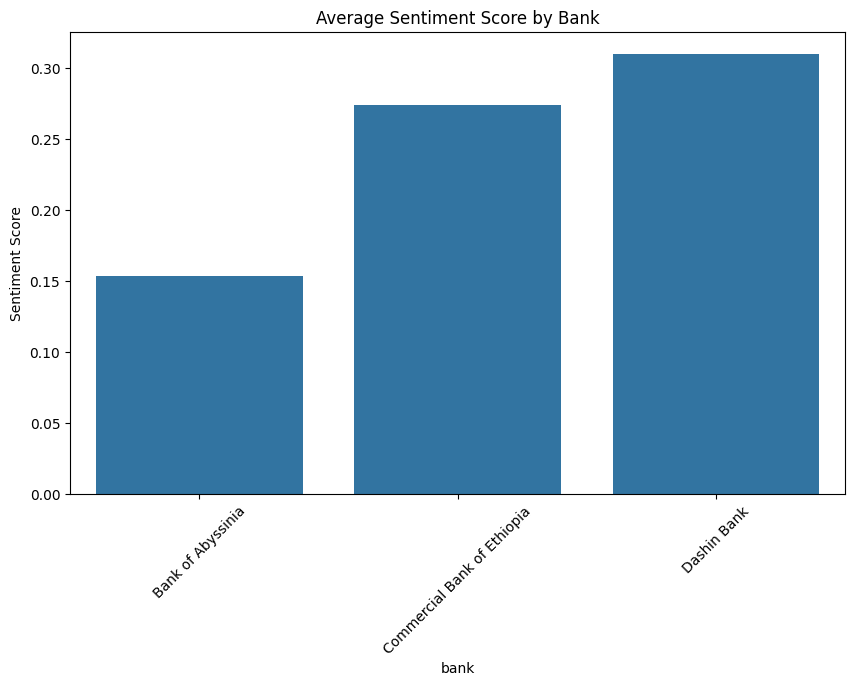

In [3]:
# Plot 1: Sentiment Bar (Avg per Bank)
sentiment_df = df.groupby('bank_name')['sentiment_score'].mean().reset_index()
sentiment_df.columns = ['bank', 'sentiment']  # For consistency
plt.figure(figsize=(10, 6))
sns.barplot(data=sentiment_df, x='bank', y='sentiment')
plt.title('Average Sentiment Score by Bank')
plt.xticks(rotation=45)
plt.ylabel('Sentiment Score')
plt.savefig(f'{OUTPUT_DIR}/sentiment_bar.png', dpi=300, bbox_inches='tight')
plt.show()

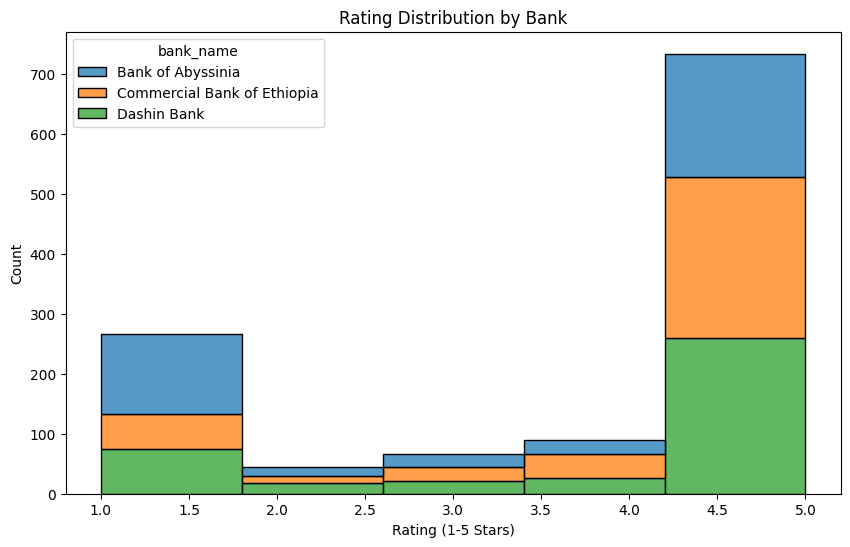

In [4]:
# Plot 2: Rating Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='rating', hue='bank_name', multiple='stack', bins=5)
plt.title('Rating Distribution by Bank')
plt.xlabel('Rating (1-5 Stars)')
plt.savefig(f'{OUTPUT_DIR}/rating_hist.png', dpi=300, bbox_inches='tight')
plt.show()

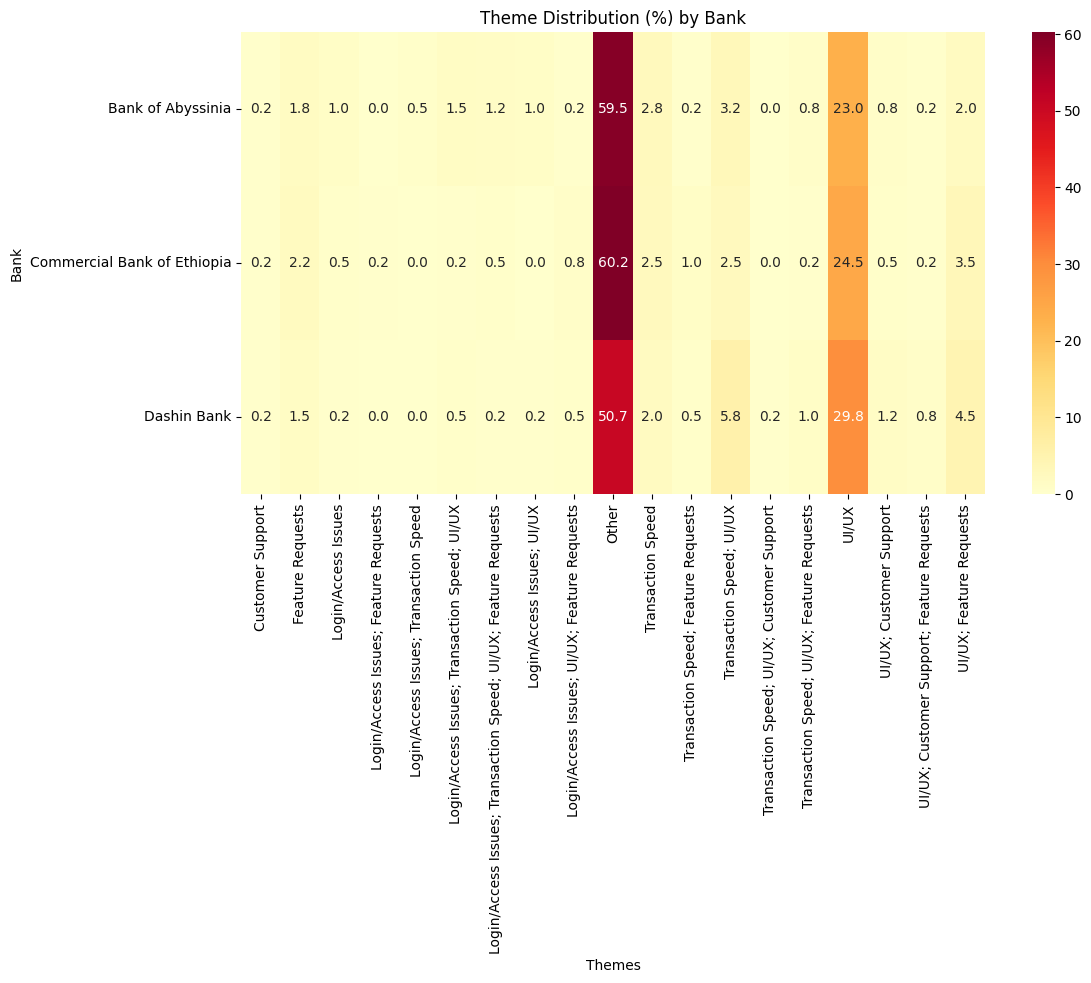

In [5]:
# Plot 3: Theme Heatmap
theme_pivot = df.groupby(['bank_name', 'theme']).size().unstack(fill_value=0)
theme_pivot = theme_pivot.div(theme_pivot.sum(axis=1), axis=0) * 100  # %
plt.figure(figsize=(12, 6))
sns.heatmap(theme_pivot, annot=True, cmap='YlOrRd', fmt='.1f')
plt.title('Theme Distribution (%) by Bank')
plt.ylabel('Bank')
plt.xlabel('Themes')
plt.savefig(f'{OUTPUT_DIR}/theme_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

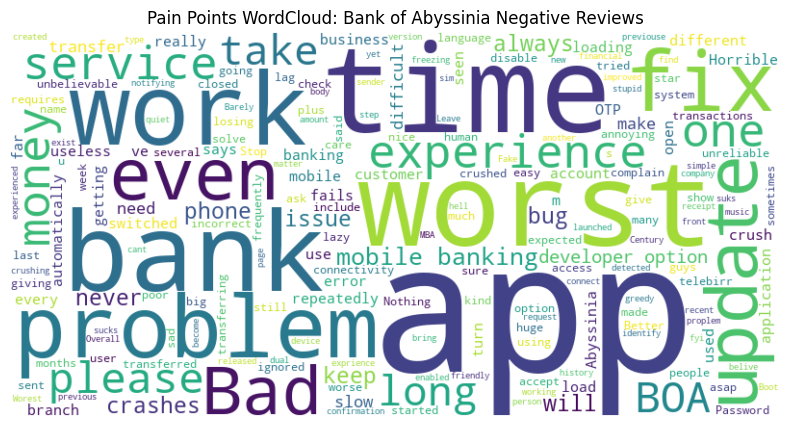

In [6]:
# Plot 4: Keyword Cloud (Neg for first bank as example, e.g., Bank of Abyssinia)
first_bank = df['bank_name'].iloc[0]
neg_reviews = df[(df['bank_name'] == first_bank) & 
                 (df['sentiment_label'] == 'negative')]['review_text'].dropna()
neg_text = ' '.join(neg_reviews)
if neg_text:
    wc = WordCloud(width=800, height=400, background_color='white').generate(neg_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Pain Points WordCloud: {first_bank} Negative Reviews')
    plt.savefig(f'{OUTPUT_DIR}/pain_cloud_{first_bank.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print(f'No negative reviews for {first_bank}')

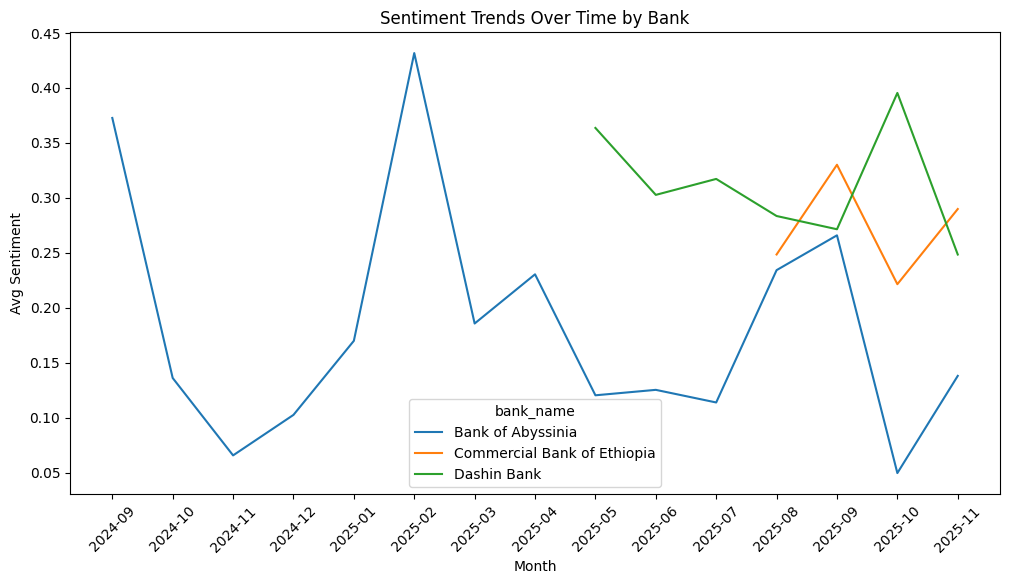

All 5 plots generated in figs/

Ethics: Reviews may skew negative (extreme opinions); supplement with balanced surveys.


In [7]:
# Plot 5: Sentiment Trend Over Time
df_trend = df.groupby(['bank_name', df['review_date'].dt.to_period('M')])['sentiment_score'].mean().reset_index()
df_trend['review_date'] = df_trend['review_date'].astype(str)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trend, x='review_date', y='sentiment_score', hue='bank_name')
plt.title('Sentiment Trends Over Time by Bank')
plt.xticks(rotation=45)
plt.ylabel('Avg Sentiment')
plt.xlabel('Month')
plt.savefig(f'{OUTPUT_DIR}/sentiment_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print('All 5 plots generated in figs/')
print('\nEthics: Reviews may skew negative (extreme opinions); supplement with balanced surveys.')